#**📈Timeseries and Heatmap Visualization for Extreme Events**

> **Updated** 19-Dec-2025 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will display timeseries of extreme phenomena such as anomalously high temperatures(AHT), heavy rainfall(HR), and marine heatwaves(MHW) for a specific grid point in East Asia.

Data Directory: 0.ExtremeEvents_ERA5_OISST, 1.Daily_ERA5_OISST

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Download data**

Create FIRST directories if needed with the following line OR by yourself.

You can change the following path.

In [2]:
#!mkdir -p /content/drive/MyDrive/APCC/Data/

Start downloading with wget.

Uncomment and run below.

In [3]:
#!wget --content-disposition "wget --content-disposition "https://www.dropbox.com/scl/fo/d3x654sonyblxni7ha3gm/ABzxk80RwyxIx6Hi_4A400g?rlkey=arvb3pmacdtrvkav367ld92kx&st=ryf7m45o&dl=0"

Run the following line to unzip the data OR by yourself.

PATH_Data will be the path where the downloaded data is saved.

In [4]:
#!unzip -qq '/PATH_Data/DataFilesforEastAsiaClimateExtremes.zip' -d '/content/drive/MyDrive/APCC/Data/'

### **Set paths**

CHANGE the following paths if needed!

In [5]:
PATH_data1 = "/content/drive/MyDrive/APCC/Data/0.ExtremeEvents_ERA5_OISST/"
PATH_data2 = "/content/drive/MyDrive/APCC/Data/1.Daily_ERA5_OISST/"
PATH_save = "/content/drive/MyDrive/APCC/Results/"

### **Import libraries**

In [6]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from matplotlib.gridspec import GridSpec
import os
import matplotlib.ticker as mtick
from scipy import stats
import seaborn as sns
from scipy.stats import linregress
from pprint import pprint

### **Set options**

***"You CAN change the target variable, the coordinates, and the start and end dates BELOW."***

In [7]:
# === Set options
thr = '90'
sdate, edate = '2024-01-01', '2024-12-31'

# --- Heavy rainfall(HR)
varname0 = 'HR'
crt = 'D1G3' # _D1G3, _D3G3
lat_oi, lon_oi = 36.235774, 127.371063 # Over land

# --- High temperatures(AHT)
# varname0 = 'AHT'
# crt = 'D3G5' # _D5G2, _D3G5
# lat_oi, lon_oi = 36.235774, 127.371063 # Over land

# --- Marine heatwaves(MHW)
# varname0 = 'MHW'
# crt = 'D5G2' # _D5G2, _D3G5
# lat_oi, lon_oi = 35.076912, 129.869889 # Over ocean for MHW

### **Load data**

In [8]:
# === Load event and raw data
if varname0 == 'HR':
    with open(os.path.join(PATH_data1, 'event.HR.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.TP.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)
elif varname0 == 'AHT':
    with open(os.path.join(PATH_data1, 'event.AHT.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.T2M.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)
elif varname0 == 'MHW':
    with open(os.path.join(PATH_data1, 'event.MHW.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data1 = pickle.load(file)
    with open(os.path.join(PATH_data2, f'daily.SST.era5.1940-2024.EA1.5.pkl'),'rb') as file:
        data2 = pickle.load(file)

print(data1.keys())
print(data2.keys())

/tmp/ipython-input-4072593746.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data1 = pickle.load(file)
/tmp/ipython-input-4072593746.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use

dict_keys(['lat', 'lon', 'dates', 'dates_YM', 'event90_D1G3', 'event90_D3G3', 'event95_D1G3', 'event95_D3G3', 'ImF90_moving7d', 'EDays90_moving7d', 'IntMx90_moving7d', 'ImF95_moving7d', 'EDays95_moving7d', 'IntMx95_moving7d', 'ImF90_mon', 'EDays90_mon', 'IntMx90_mon', 'ImF95_mon', 'EDays95_mon', 'IntMx95_mon'])
dict_keys(['tp', 'lat', 'lon', 'dates', 'dates_YM', 'clim', 'thresh90', 'thresh95'])


In [9]:
# === Assign variables
lat, lon  = data1['lat'], data1['lon']
dates = data1['dates']
print('lat lon shapes:', lat.shape, lon.shape)

lat lon shapes: (19,) (19,)


In [10]:
varname = next(iter(data2))
values = data2[varname]
print('varname:', varname)
print('values shape:', values.shape)

varname: tp
values shape: (31046, 19, 19)


In [11]:
thresh = data2[f'thresh{thr}']
clim = data2['clim']
events = data1[f'event{thr}_{crt}']
print(events.keys())

dict_keys(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end', 'date_peak', 'index_start', 'index_end', 'index_peak', 'duration', 'duration_moderate', 'duration_strong', 'duration_severe', 'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var', 'intensity_cumulative', 'intensity_max_relThresh', 'intensity_mean_relThresh', 'intensity_var_relThresh', 'intensity_cumulative_relThresh', 'intensity_max_abs', 'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs', 'category', 'rate_onset', 'rate_decline', 'n_events'])


### **Select closest grid point**

In [12]:
# === grid point of interest
ly = lat[np.abs(lat - lat_oi).argmin()]
lx = lon[np.abs(lon - lon_oi).argmin()]
print('closest lat and lon:', ly, lx)
ly_,lx_ = str(ly)+'N',str(lx)+'E'
iy, ix = np.argwhere(lat==ly)[0][0], np.argwhere(lon==lx)[0][0]

closest lat and lon: 36.0 127.5


### **Create binary event array**

In [13]:
# === Create binary event array using index_start and index_end
# Initialize array
event_binary = np.zeros(len(dates), dtype=int)

# Get the start and end indices of the event at the specific grid point
start_indices = events['index_start'][ly_, lx_]  # event start indices
end_indices = events['index_end'][ly_, lx_]      # event end indices

# Set the range from start_idx to end_idx (inclusive) to 1
for start_idx, end_idx in zip(start_indices, end_indices):
    event_binary[start_idx:end_idx+1] = 1

print(f"Total data size: {event_binary.shape[0]}")
print(f"Total event days: {np.sum(event_binary)}")
print(f"Percentage of event days: {np.sum(event_binary)/len(event_binary)*100:.2f}%")

Total data size: 31046
Total event days: 4323
Percentage of event days: 13.92%


### **Prepare dataframe for plotting**

In [14]:
values_pt = values[:,iy,ix]
thresh_pt = np.array(thresh[ly_,lx_])
clim_pt = np.array(clim[ly_,lx_])
df = pd.DataFrame({'date':dates, 'value':values_pt, 'thresh':thresh_pt, 'clim':clim_pt, 'event':event_binary})
df['date'] = pd.to_datetime(df['date'])

mask = (df['date'] >= sdate) & (df['date'] <= edate)
df_selected = df.loc[mask].copy()
dates_selected = df_selected['date']
values_selected = df_selected['value']
thresh_selected = df_selected['thresh']
clim_selected = df_selected['clim']
if varname0 == 'HR':
    values_selected *= 1000
    thresh_selected *= 1000
    clim_selected *= 1000
elif varname0 == 'AHT':
    values_selected -= 273.15
    thresh_selected -= 273.15
    clim_selected -= 273.15

## **Visualization 1. Daily timeseries with extreme events**

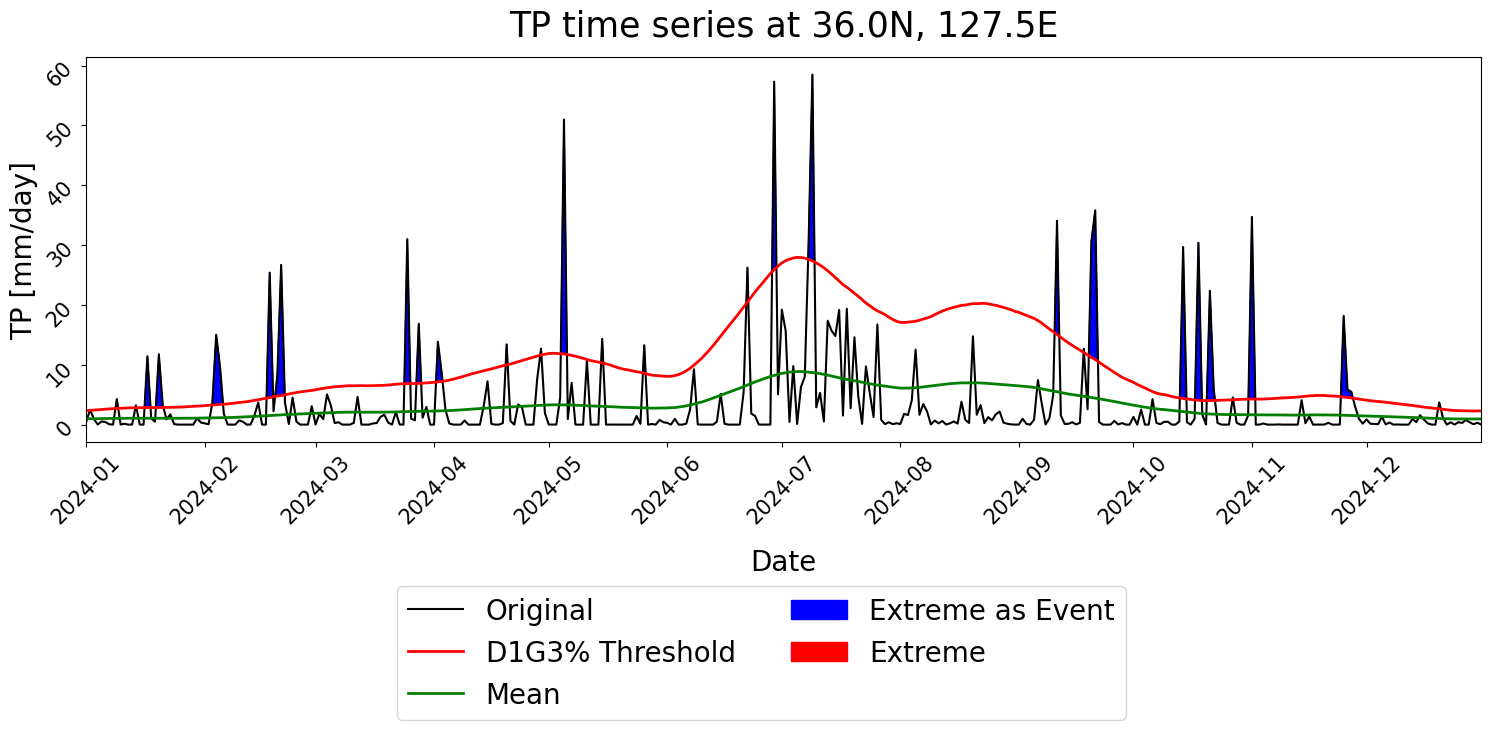

In [15]:
# --- Raw timeseries with extreme events
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(dates_selected, values_selected, 'k-', linewidth=1.5, label='Original')
ax.plot(dates_selected, thresh_selected, 'r-', linewidth=2, label=f'{crt}% Threshold')
ax.plot(dates_selected, clim_selected, 'g-', linewidth=2, label='Mean')
ymin, ymax = ax.get_ylim()
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 1),
    color='blue',
    interpolate=True,
    label='Extreme as Event'
)
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 0),
    color='red',
    interpolate=True,
    label='Extreme'
)
ax.set_xlim(dates_selected.min(), dates_selected.max())
ax.set_ylim(ymin, ymax)  # y축 범위 다시 설정
ax.set_ylabel('TP [mm/day]' if varname0=='HR' else
              'SST [°C]' if varname0=='MHW' else
              'T2m [°C]',
              fontsize=20)
ax.set_xlabel('Date', fontsize=20, labelpad=15)
ax.tick_params(axis='both', which='major', labelsize=15, rotation=45)
ax.set_title(f"{varname.upper()} time series at {ly_}, {lx_}", fontsize=25, pad=15)
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     fontsize=18,
# )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, fontsize=20)

plt.savefig(os.path.join(PATH_save, f"{varname0}_thresh{thr}_daily_timeseries.png"), dpi=100, bbox_inches='tight')
plt.show()

## **Visualization 2. Yearly timeseries with event sums**

Aggregate yearly event sums and calculate linear trend.

In [16]:
# --- Yearly timeseries for event sums
start_period = '1940'
end_period   = '2024'
df['year'] = df['date'].dt.to_period('Y')
df_period = df[(df['year'] >= start_period) & (df['year'] <= end_period)].copy()
df_period.set_index('date', inplace=True)
yearly = df_period['event'].resample('Y').sum()

# Linear regression
years = np.array([d.year for d in yearly.index])
years_norm = years - years.min()
counts = yearly.values
slope, intercept, r_value, p_value, std_err = stats.linregress(years_norm, counts)
trend = intercept + slope * years_norm
eq = f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.3f}'

/tmp/ipython-input-2082078455.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df_period['event'].resample('Y').sum()


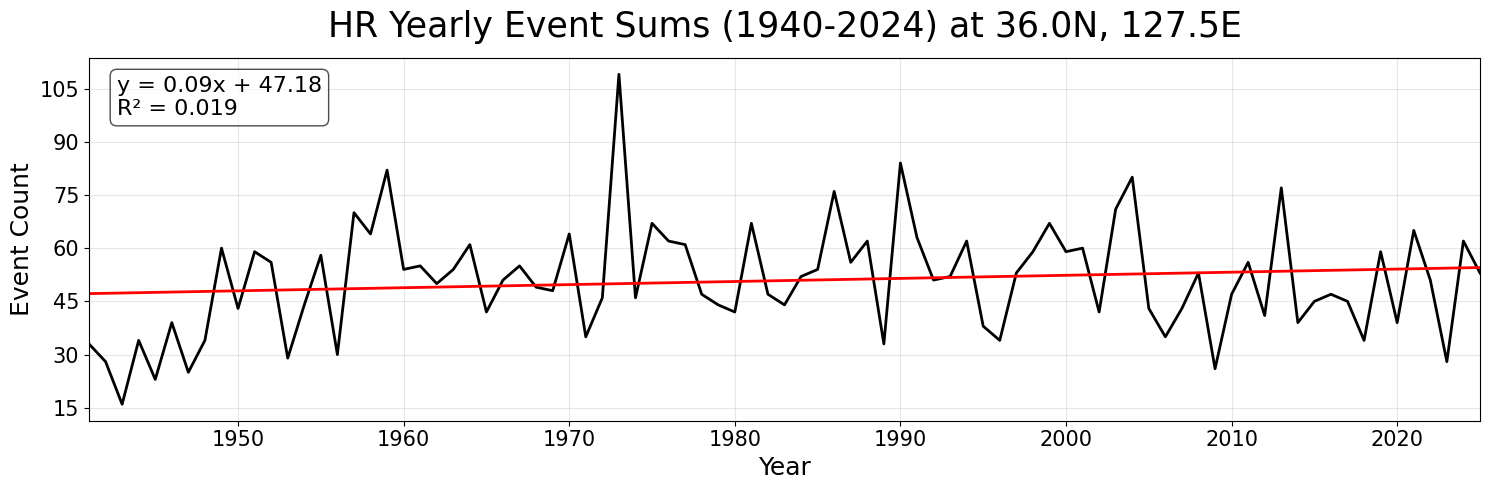

In [17]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(yearly.index, yearly.values, color='k', linewidth=2, label='Yearly Sum')
ax.plot(yearly.index, trend, 'r-', linewidth=2, label='Trend Line')
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Event Count', fontsize=18)
ax.set_title(f'{varname0} Yearly Event Sums ({start_period}-{end_period}) at {ly_}, {lx_}', fontsize=25, pad=15)
ax.tick_params(axis='both', which='major', labelsize=15)#, rotation=45)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.text(0.02, 0.95, eq, transform=ax.transAxes,
        fontsize=16, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax.margins(x=0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATH_save, f"{varname0}_{crt}_yearly_eventsums_timeseries.png"), dpi=100, bbox_inches='tight')
plt.show()

## **Visualization 3. Monthly heatmap with event sums + Trend annotations**

In [18]:
# === Monthly Heatmap plot with event sums + trend annotations
start_period = '1940'
end_period   = '2024'

# Ensure date and event columns
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Filter desired period
df_period = df[(df['year'] >= int(start_period)) & (df['year'] <= int(end_period))].copy()

# Group by year and month, summing events
monthly_sum = df_period.groupby(['year', 'month'])['event'].sum().reset_index()

# Pivot to wide format: rows=month, cols=year
heat_df = monthly_sum.pivot(index='month', columns='year', values='event')

# Compute trend (slope) for each month
slopes = {}
years = heat_df.columns.values
years_norm = years - years.min()
for month in heat_df.index:
    counts = heat_df.loc[month].values
    slope, _, _, p_value, _ = linregress(years_norm, counts)
    slopes[month] = slope

# Determine trend direction
trend_label = {m: '(+)' if slopes[m] > 0 else '(-)' if slopes[m] < 0 else '-' for m in heat_df.index}

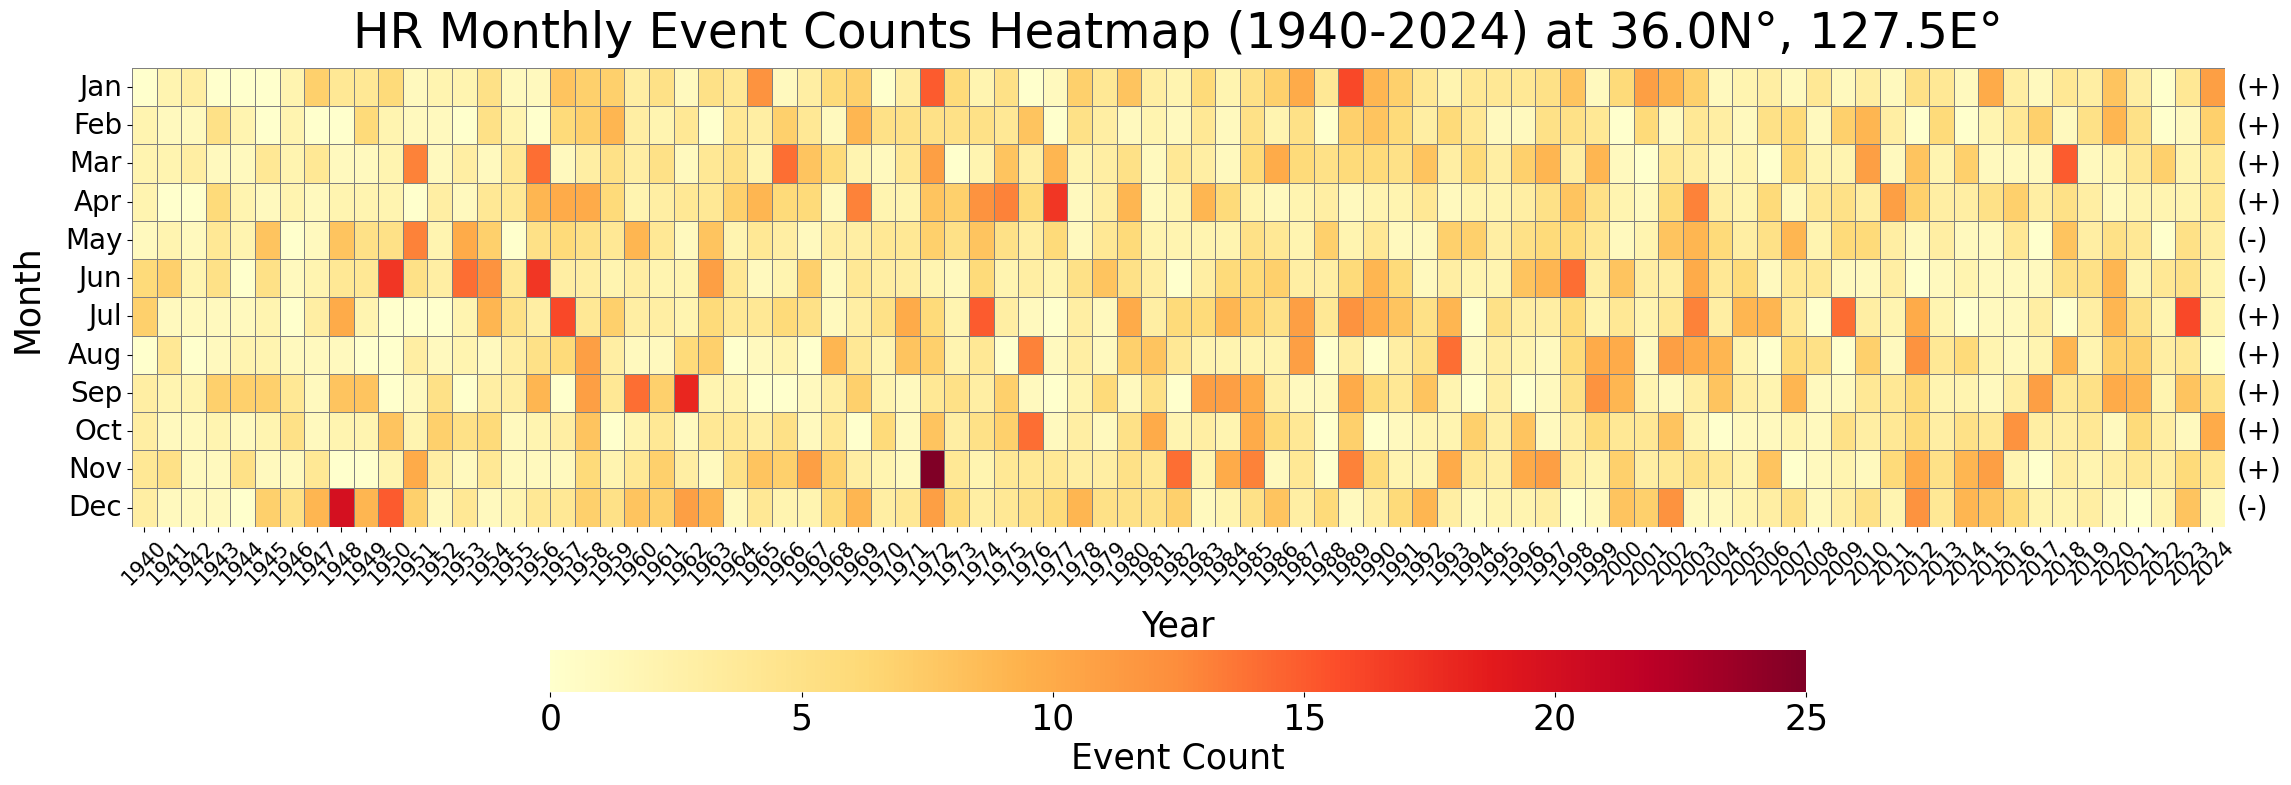

In [19]:
fig, ax = plt.subplots(figsize=(23, 8))
cbar_kws = {
    'label': 'Event Count',
    'orientation': 'horizontal',
    'pad': 0.18,           # colorbar와 플롯 사이 여백
    'shrink': 0.6,         # colorbar 길이 비율
    'ticks': None,          # 자동 눈금
    'aspect': 30
}
sns.heatmap(
    heat_df,
    cmap='YlOrRd',
    cbar_kws=cbar_kws,
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)   # colorbar tick fontsize
cbar.ax.xaxis.label.set_size(25)    # colorbar label fontsize
ax.set_xlabel('Year', fontsize=25, labelpad=15)
ax.set_ylabel('Month', fontsize=25, labelpad=15)
ax.set_title(f'{varname0} Monthly Event Counts Heatmap ({start_period}-{end_period}) at {ly_}°, {lx_}°', fontsize=35, pad=15)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(0.5, 12.5))
ax.set_yticklabels(months, rotation=0, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=15)
for idx, month in enumerate(heat_df.index):
    ax.text(
        len(years) + 0.5,
        idx + 0.5,
        trend_label[month],
        va='center',
        ha='left',
        fontsize=20
    )
plt.subplots_adjust(right=0.9)
plt.tight_layout()

plt.savefig(os.path.join(PATH_save, f"{varname0}_{crt}_monthly_eventsums_heatmap.png"), dpi=100, bbox_inches='tight')
plt.show()